In [ ]:
# ##############################################################
# MobileSAM LoRA Finetuning for Prompt Robustness on ACDC
#
# Pipeline:
#   1  Install + imports
#   2  Config (single source of truth for all constants)
#   3  Shared helpers (dice, box jitter, viz utils)
#   4  Load MobileSAM + build predictor
#   5  Load ACDC data (multi-class, multiple patients)
#   6  Sanity viz: structures + boxes
#   7  Per-structure robustness — BEFORE (stock MobileSAM)
#   8  Per-structure BEFORE charts
#   9  LoRA wiring (decoder + prompt encoder)
#   10 Training dataset (jittered-box augmentation)
#   11 Train loop + loss curve
#   12 Per-structure robustness — AFTER (LoRA model)
#   13 Before/after charts (overall + per structure)
#   14 Before/after visual panels
#   15 Final summary table + save
# ##############################################################

In [1]:
# ==============================================================
# CELL 1 — Install + imports
# ==============================================================
!pip -q install git+https://github.com/ChaoningZhang/MobileSAM.git
!pip -q install peft loralib nibabel scipy matplotlib

import os, math, random, copy, time
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from scipy import ndimage

print("torch:", torch.__version__, "cuda:", torch.cuda.is_available())
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

  Preparing metadata (setup.py) ... done
torch: 2.11.0+cu128 cuda: True


In [2]:
# ==============================================================
# CELL 2 — Config (single source of truth)
# Every other cell reads from here. Never redefine these elsewhere.
# ==============================================================
class CFG:
    # Reproducibility
    SEED         = 42

    # Noise sweep (bounding-box jitter in pixels)
    SIGMA_VALUES = [0.0, 0.05, 0.10, 0.15, 0.20, 0.30]
    TRAIN_SIGMA  = 0.20
    N_TRIALS=30             # eval trials per sigma (median + IQR)

    # ACDC label convention (verified in CELL 5; warns if different)
    #   background=0, RV=1, myocardium=2, LV=3
    LABELS = {"RV": 1, "MYO": 2, "LV": 3}

    # Consistent per-structure colors across ALL figures
    COLORS = {"RV": "#1f77b4", "MYO": "#2ca02c", "LV": "#d62728"}

    # Clinical/quality reference line
    DICE_THRESHOLD = 0.80

    # LoRA
    LORA_R         = 8
    LORA_ALPHA     = 16
    LORA_DROPOUT   = 0.05
    TRAIN_TARGETS  = ("mask_decoder", "prompt_encoder")  # freeze image encoder

    # Training
    EPOCHS         = 20
    BATCH_SIZE     = 4
    LR             = 1e-4
    VAL_FRACTION   = 0.2

    # Paths (edit to your environment)
    MOBILESAM_CKPT = "/content/mobile_sam.pt"
    ACDC_ROOT      = "/content/ACDC"     # dir of patient folders or preprocessed slices
    OUT_DIR        = "/content/drive/MyDrive/ACDC_outputs"

os.makedirs(CFG.OUT_DIR, exist_ok=True)

def set_all_seeds(seed=CFG.SEED):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)

set_all_seeds()
print("Config loaded. Structures:", list(CFG.LABELS), "| sigmas:", CFG.SIGMA_VALUES)

Config loaded. Structures: ['RV', 'MYO', 'LV'] | sigmas: [0.0, 0.05, 0.1, 0.15, 0.2, 0.3]


In [4]:
from google.colab import drive
import os
if not os.path.ismount("/content/drive"):
    drive.mount("/content/drive", force_remount=True)

os.makedirs(CFG.OUT_DIR, exist_ok=True)

# prove we can actually write there
_test = os.path.join(CFG.OUT_DIR, "_write_test.txt")
with open(_test, "w") as f:
    f.write("ok")
assert os.path.exists(_test), "OUT_DIR is not writable!"
os.remove(_test)
print(f"✓ OUT_DIR is on Drive and writable: {CFG.OUT_DIR}")

Mounted at /content/drive
✓ OUT_DIR is on Drive and writable: /content/drive/MyDrive/ACDC_outputs


In [32]:
# ==============================================================
# CELL 3 — Shared helpers (defined ONCE, used everywhere)
# ==============================================================
def dice_score(pred, gt, eps=1e-6):
    """Dice between two binary masks of identical H,W."""
    pred = np.asarray(pred).astype(bool)
    gt   = np.asarray(gt).astype(bool)
    inter = np.logical_and(pred, gt).sum()
    denom = pred.sum() + gt.sum()
    if denom == 0:
        return 1.0          # both empty -> perfect agreement
    return float((2.0 * inter + eps) / (denom + eps))


def dice_torch(pred_logits, gt_mask, eps=1e-6):
    """Differentiable soft Dice loss for training (pred_logits: B,1,H,W)."""
    pred = torch.sigmoid(pred_logits)
    gt   = gt_mask.float()
    inter = (pred * gt).sum(dim=(1, 2, 3))
    denom = pred.sum(dim=(1, 2, 3)) + gt.sum(dim=(1, 2, 3))
    dice  = (2 * inter + eps) / (denom + eps)
    return 1.0 - dice.mean()


def box_from_mask(mask, pad=0):
    """Tight box [x0,y0,x1,y1] around a binary mask."""
    ys, xs = np.where(mask > 0)
    if len(xs) == 0:
        return None
    x0, x1 = xs.min(), xs.max()
    y0, y1 = ys.min(), ys.max()
    return np.array([x0 - pad, y0 - pad, x1 + pad, y1 + pad], dtype=int)


def make_noisy_box(clean_box, sigma, seed, W, H):
    """Deterministic jittered box. Identical output for any caller with
    the same (sigma, seed) — guarantees paired comparisons everywhere."""
    rng = np.random.default_rng(seed)
    if sigma == 0:
        b = clean_box.copy().astype(int)
    else:
        b = clean_box + rng.normal(0, sigma, 4).astype(int)
    b[0] = int(np.clip(b[0], 0, W - 1)); b[1] = int(np.clip(b[1], 0, H - 1))
    b[2] = int(np.clip(b[2], 0, W - 1)); b[3] = int(np.clip(b[3], 0, H - 1))
    if b[0] >= b[2]: b[2] = min(b[0] + 10, W - 1)
    if b[1] >= b[3]: b[3] = min(b[1] + 10, H - 1)
    return b


def median_trial_index(dice_list):
    arr = np.array(dice_list)
    return int(np.argmin(np.abs(arr - np.median(arr))))


def med_iqr(dice_lists_by_sigma, sigmas=CFG.SIGMA_VALUES):
    med = [np.median(dice_lists_by_sigma[s]) for s in sigmas]
    q1  = [np.percentile(dice_lists_by_sigma[s], 25) for s in sigmas]
    q3  = [np.percentile(dice_lists_by_sigma[s], 75) for s in sigmas]
    return np.array(med), np.clip(q1, 0, 1), np.clip(q3, 0, 1)


def to_rgb(gray):
    """ACDC slices are single-channel; SAM expects HxWx3 uint8."""
    g = gray.astype(np.float32)
    g = (g - g.min()) / (np.ptp(g) + 1e-8)   # was g.ptp() — removed in NumPy 2.0
    g = (g * 255).astype(np.uint8)
    return np.stack([g, g, g], axis=-1)

def make_noisy_box_prop(clean_box, frac, seed, W, H):
    """Jitter scaled to box size. Each coordinate is perturbed by
    Normal(0, frac * box_dimension), so frac=0.10 ≈ 10% of the box.
    Deterministic in (frac, seed) -> identical boxes for paired runs."""
    rng = np.random.default_rng(seed)
    bw = max(int(clean_box[2] - clean_box[0]), 1)
    bh = max(int(clean_box[3] - clean_box[1]), 1)
    if frac == 0:
        b = clean_box.copy().astype(int)
    else:
        noise = rng.normal(0, 1, 4) * np.array([bw, bh, bw, bh]) * frac
        b = (clean_box + noise).astype(int)
    b[0] = int(np.clip(b[0], 0, W - 1)); b[1] = int(np.clip(b[1], 0, H - 1))
    b[2] = int(np.clip(b[2], 0, W - 1)); b[3] = int(np.clip(b[3], 0, H - 1))
    if b[0] >= b[2]: b[2] = min(b[0] + 10, W - 1)
    if b[1] >= b[3]: b[3] = min(b[1] + 10, H - 1)
    return b

  # ==============================================================
# ADD TO CELL 4 — Bounded jitter helper
# Resamples until the noisy box retains minimum overlap with
# the true structure mask. Fallback to clean box if no valid
# sample found within max_tries.
# ==============================================================
def box_iou(b1, b2):
    """IoU between two boxes [x0,y0,x1,y1]."""
    ix0 = max(b1[0], b2[0]); iy0 = max(b1[1], b2[1])
    ix1 = min(b1[2], b2[2]); iy1 = min(b1[3], b2[3])
    inter = max(0, ix1-ix0) * max(0, iy1-iy0)
    if inter == 0:
        return 0.0
    a1 = (b1[2]-b1[0]) * (b1[3]-b1[1])
    a2 = (b2[2]-b2[0]) * (b2[3]-b2[1])
    return inter / (a1 + a2 - inter)


def make_noisy_box_bounded(clean_box, frac, rng, W, H,
                            min_iou=0.30, max_tries=50):
    """
    Proportional jitter with IoU floor.
    Keeps resampling until the jittered box overlaps the clean box
    by at least min_iou. Falls back to clean box if max_tries exceeded.
    min_iou=0.30 means the box must still cover 30% of the true region.
    """
    if frac == 0:
        return clean_box.copy().astype(int)

    for _ in range(max_tries):
        candidate = make_noisy_box_prop(
            clean_box, frac,
            seed=int(rng.integers(1e9)), W=W, H=H)
        if box_iou(candidate, clean_box) >= min_iou:
            return candidate

    # fallback — could not find a valid sample, use clean box
    return clean_box.copy().astype(int)


# Axis-label helper so every chart reads consistently
JITTER_XLABEL = "Box jitter (fraction of box size)"

from mobile_sam.utils.transforms import ResizeLongestSide


def encode_image(rgb):
    x = transform.apply_image(rgb)
    x = torch.as_tensor(x, device=DEVICE).permute(2, 0, 1).contiguous()[None]
    input_size = tuple(x.shape[-2:])      # capture BEFORE preprocess/padding
    x = sam.preprocess(x)
    with torch.no_grad():
        emb = sam.image_encoder(x)
    return emb, input_size                # return the correct pre-pad size

def forward_one(rgb, box, gt):
    H, W = rgb.shape[:2]
    emb, input_size = encode_image(rgb)
    box_t = transform.apply_boxes(box[None, :], (H, W))
    box_t = torch.as_tensor(box_t, dtype=torch.float, device=DEVICE)
    sparse, dense = sam.prompt_encoder(points=None, boxes=box_t, masks=None)
    low_res, _ = sam.mask_decoder(
        image_embeddings=emb,
        image_pe=sam.prompt_encoder.get_dense_pe(),
        sparse_prompt_embeddings=sparse,
        dense_prompt_embeddings=dense,
        multimask_output=False)
    logits = sam.postprocess_masks(low_res, input_size, (H, W))
    gt_t = torch.as_tensor(gt, device=DEVICE)[None, None]
    return logits, gt_t

print("Helpers ready.")

Helpers ready.


In [6]:
import mobile_sam, os, glob, shutil

# The weights file is included in the installed package
pkg_dir = os.path.dirname(mobile_sam.__file__)
hits = glob.glob(os.path.join(pkg_dir, "**", "*.pt"), recursive=True)
print("Found .pt files in package:", hits)

if hits:
    shutil.copy(hits[0], CFG.MOBILESAM_CKPT)
    print(f"Copied {hits[0]} -> {CFG.MOBILESAM_CKPT}")
else:
    print("No .pt in package — download from the repo's weights folder instead.")

Found .pt files in package: []
No .pt in package — download from the repo's weights folder instead.


In [7]:
# Fallback: pull the official checkpoint from the MobileSAM repo
!wget -q https://github.com/ChaoningZhang/MobileSAM/raw/master/weights/mobile_sam.pt \
    -O /content/mobile_sam.pt
!ls -lh /content/mobile_sam.pt

-rw-r--r-- 1 root root 39M Jul  2 18:59 /content/mobile_sam.pt


In [8]:
# ==============================================================
# CELL 4 — Load MobileSAM + predictor
# ==============================================================
from mobile_sam import sam_model_registry, SamPredictor

sam = sam_model_registry["vit_t"](checkpoint=CFG.MOBILESAM_CKPT)
sam.to(DEVICE).eval()
predictor = SamPredictor(sam)

transform = ResizeLongestSide(sam.image_encoder.img_size)

n_params = sum(p.numel() for p in sam.parameters())
print(f"MobileSAM loaded: {n_params/1e6:.2f}M params on {DEVICE}")

torch.save(sam.state_dict(), f"{CFG.OUT_DIR}/mobilesam_stock_baseline.pt")
print("Stock baseline saved to Drive.")

# Keep an untouched copy of the original weights for the BEFORE experiment,
# so finetuning later cannot retroactively change the baseline.
import copy as _copy
sam_state_backup = _copy.deepcopy(sam.state_dict())
print("Baseline weights backed up.")

MobileSAM loaded: 10.13M params on cuda
Stock baseline saved to Drive.
Baseline weights backed up.


In [9]:
import glob, os

# Mount Drive if your data lives there (safe to run even if already mounted)
try:
    from google.colab import drive
    drive.mount('/content/drive')
except Exception as e:
    print("Drive not mounted:", e)

print("\n--- Searching for data ---")
patterns = {
    "patient folders": "/content/**/patient[0-9]*",
    "NIfTI files":     "/content/**/*.nii*",
    "npy arrays":      "/content/**/*.npy",
    "npz arrays":      "/content/**/*.npz",
}
found = {}
for label, pat in patterns.items():
    hits = glob.glob(pat, recursive=True)
    found[label] = hits
    print(f"{label}: {len(hits)}")
    for h in hits[:5]:
        print("   ", h)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

--- Searching for data ---
patient folders: 900
    /content/drive/MyDrive/ACDC/ACDC/database/testing/patient150
    /content/drive/MyDrive/ACDC/ACDC/database/testing/patient148
    /content/drive/MyDrive/ACDC/ACDC/database/testing/patient149
    /content/drive/MyDrive/ACDC/ACDC/database/testing/patient147
    /content/drive/MyDrive/ACDC/ACDC/database/testing/patient146
NIfTI files: 750
    /content/drive/MyDrive/ACDC/ACDC/database/testing/patient150/patient150_frame01.nii.gz
    /content/drive/MyDrive/ACDC/ACDC/database/testing/patient150/patient150_4d.nii.gz
    /content/drive/MyDrive/ACDC/ACDC/database/testing/patient150/patient150_frame12_gt.nii.gz
    /content/drive/MyDrive/ACDC/ACDC/database/testing/patient150/patient150_frame12.nii.gz
    /content/drive/MyDrive/ACDC/ACDC/database/testing/patient150/patient150_frame01_gt.nii.gz
npy arrays: 0
npz arrays

In [10]:
# ==============================================================
# CELL 5 — Load ACDC data (multi-class, multiple patients)
# Data lives in Google Drive (standard ACDC NIfTI layout).
# ==============================================================
import glob
import nibabel as nib

# ---- CORRECT PATH (was /content/ACDC, which doesn't exist) ----
CFG.ACDC_ROOT = "/content/drive/MyDrive/ACDC/ACDC/database/training"
assert os.path.isdir(CFG.ACDC_ROOT), f"ACDC_ROOT not found: {CFG.ACDC_ROOT}"


def load_acdc_slices(root, max_patients=None):
    """Standard ACDC: patientXXX/patientXXX_frameYY(.nii.gz / _gt.nii.gz).
    Returns list of dicts {img, mask, patient, z}. Skips empty slices."""
    slices = []
    patient_dirs = sorted(glob.glob(os.path.join(root, "patient*")))
    if max_patients:
        patient_dirs = patient_dirs[:max_patients]

    for pdir in patient_dirs:
        pid = os.path.basename(pdir)
        gt_files = sorted(glob.glob(os.path.join(pdir, f"{pid}_frame*_gt.nii.gz")))
        for gtf in gt_files:
            imgf = gtf.replace("_gt.nii.gz", ".nii.gz")
            if not os.path.exists(imgf):
                continue
            vol = nib.load(imgf).get_fdata()          # H, W, Z
            seg = nib.load(gtf).get_fdata().astype(int)
            if vol.shape != seg.shape:
                print(f"  ⚠ shape mismatch {pid}: img {vol.shape} vs gt {seg.shape}; skipped")
                continue
            for z in range(vol.shape[2]):
                m = seg[:, :, z]
                if (m > 0).sum() < 30:                 # skip slices w/o structures
                    continue
                slices.append({"img": vol[:, :, z], "mask": m,
                               "patient": pid, "z": z,
                               "frame": os.path.basename(gtf)})
    return slices


slices = load_acdc_slices(CFG.ACDC_ROOT, max_patients=None)
assert len(slices) > 0, (
    "Loaded 0 slices. Check that gt files match the *_frame*_gt.nii.gz pattern.")
print(f"Loaded {len(slices)} usable slices "
      f"from {len(set(s['patient'] for s in slices))} patients.")

# ---- Verify label convention ----
present = set()
for s in slices[:300]:
    present.update(np.unique(s["mask"]).tolist())
present.discard(0)
print("Label values present:", sorted(present))
expected = set(CFG.LABELS.values())
if not expected.issubset(present):
    print("⚠ expected", expected, "found", present, "-> edit CFG.LABELS")
else:
    print("✓ Label convention matches CFG.LABELS:", CFG.LABELS)

# ---- Per-structure availability (how many slices contain each) ----
for st, lab in CFG.LABELS.items():
    n = sum(1 for s in slices if (s["mask"] == lab).sum() >= 10)
    print(f"   {st:<4} present in {n}/{len(slices)} slices")

# ---- Patient-level train/val split (no slice leakage) ----
set_all_seeds()
all_patients = sorted(set(s["patient"] for s in slices))
random.shuffle(all_patients)
n_val = max(1, int(len(all_patients) * CFG.VAL_FRACTION))
val_patients   = set(all_patients[:n_val])
train_patients = set(all_patients[n_val:])
train_slices = [s for s in slices if s["patient"] in train_patients]
val_slices   = [s for s in slices if s["patient"] in val_patients]
print(f"\nTrain: {len(train_slices)} slices / {len(train_patients)} patients | "
      f"Val: {len(val_slices)} slices / {len(val_patients)} patients")

Loaded 1839 usable slices from 100 patients.
Label values present: [1, 2, 3]
✓ Label convention matches CFG.LABELS: {'RV': 1, 'MYO': 2, 'LV': 3}
   RV   present in 1551/1839 slices
   MYO  present in 1828/1839 slices
   LV   present in 1805/1839 slices

Train: 1477 slices / 80 patients | Val: 362 slices / 20 patients


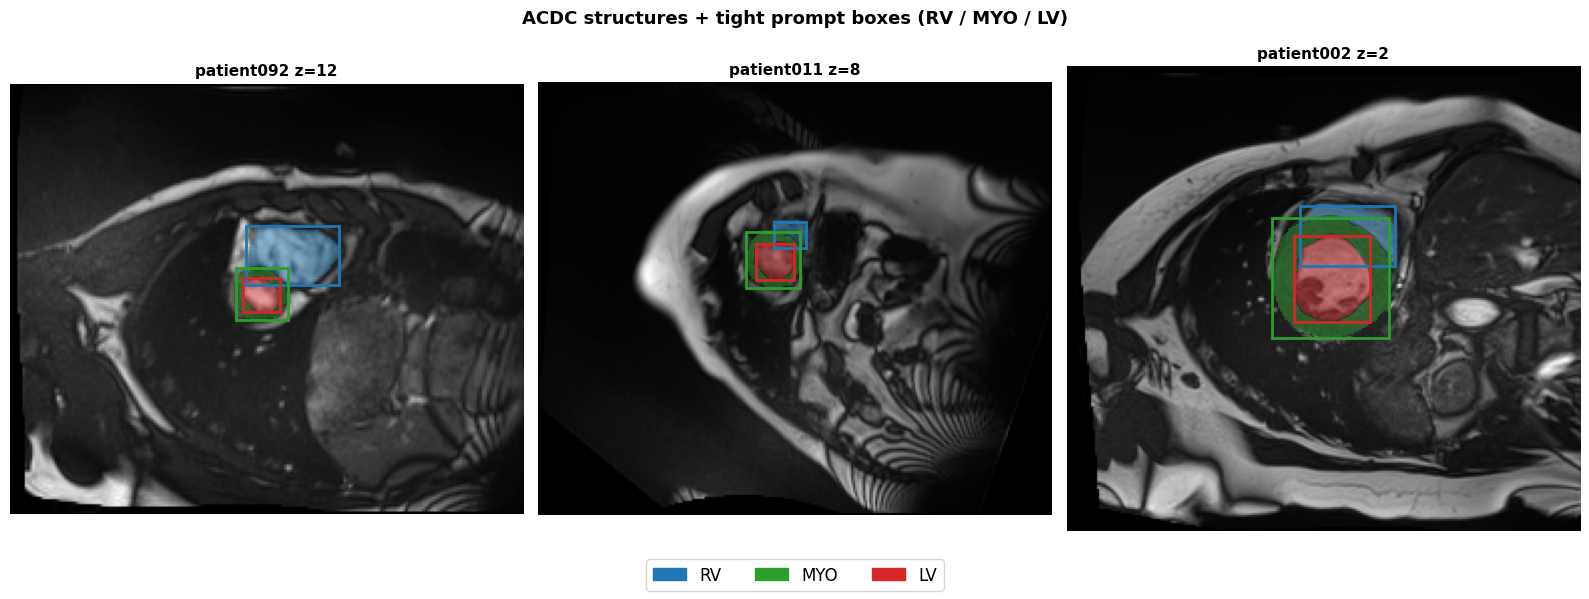

Saved: sanity_structures.png


In [11]:
# ==============================================================
# CELL 6 — Sanity viz: structures + their boxes on a few slices
# Confirms labels/colors/boxes are correct BEFORE any experiment.
# ==============================================================
def structure_mask(full_mask, struct):
    return (full_mask == CFG.LABELS[struct]).astype(np.uint8)

set_all_seeds()
viz_slices = random.sample(val_slices, min(3, len(val_slices)))

fig, axes = plt.subplots(1, 3, figsize=(16, 6))
for ax, s in zip(np.atleast_1d(axes), viz_slices):
    rgb = to_rgb(s["img"])
    H, W = rgb.shape[:2]
    ax.imshow(rgb)
    for struct in CFG.LABELS:
        m = structure_mask(s["mask"], struct)
        if m.sum() == 0:
            continue
        ax.imshow(np.ma.masked_where(m == 0, m), alpha=0.45,
                  cmap=plt.matplotlib.colors.ListedColormap([CFG.COLORS[struct]]))
        box = box_from_mask(m)
        if box is not None:
            ax.add_patch(patches.Rectangle(
                (box[0], box[1]), box[2]-box[0], box[3]-box[1],
                linewidth=2, edgecolor=CFG.COLORS[struct], facecolor='none'))
    ax.set_title(f"{s['patient']} z={s['z']}", fontsize=11, fontweight='bold')
    ax.axis('off')

# Legend
handles = [patches.Patch(color=CFG.COLORS[k], label=k) for k in CFG.LABELS]
fig.legend(handles=handles, loc='lower center', ncol=3, fontsize=12)
plt.suptitle("ACDC structures + tight prompt boxes (RV / MYO / LV)",
             fontsize=13, fontweight='bold')
plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.savefig(f"{CFG.OUT_DIR}/sanity_structures.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: sanity_structures.png")

In [12]:
# ==============================================================
# CELL 7 — Per-structure robustness experiment (reusable)
# Runs MobileSAM (whatever weights are loaded) on RV/MYO/LV
# separately, across the sigma sweep, on the VAL set.
# Returns nested dict: results[struct][sigma] = [dice per (slice,trial)]
# ==============================================================
def run_per_structure_robustness(predictor, eval_slices, tag, max_slices=None):
    if max_slices:
        eval_slices = eval_slices[:max_slices]

    results   = {st: {s: [] for s in CFG.SIGMA_VALUES} for st in CFG.LABELS}
    repr_store = {st: {s: None for s in CFG.SIGMA_VALUES} for st in CFG.LABELS}

    print(f"\n[{tag}] per-structure robustness over {len(eval_slices)} slices...")
    for si, s in enumerate(eval_slices):
        rgb = to_rgb(s["img"]); H, W = rgb.shape[:2]
        predictor.set_image(rgb)
        for struct in CFG.LABELS:
            gt = (s["mask"] == CFG.LABELS[struct]).astype(np.uint8)
            if gt.sum() < 10:
                continue
            clean_box = box_from_mask(gt)
            if clean_box is None:
                continue
            for frac in CFG.SIGMA_VALUES:
                for t in range(CFG.N_TRIALS):
                    # seed uses an index for frac so it's deterministic for floats
                    fi = CFG.SIGMA_VALUES.index(frac)
                    box = make_noisy_box_prop(
                        clean_box, frac,
                        seed=10_000*si + 1000*fi + t, W=W, H=H)
                    with torch.inference_mode():
                        m, _, _ = predictor.predict(
                            point_coords=None, point_labels=None,
                            box=box[None, :], multimask_output=False)
                    d = dice_score(m[0], gt)
                    results[struct][frac].append(d)
                    if repr_store[struct][frac] is None and t == CFG.N_TRIALS//2:
                        repr_store[struct][frac] = {
                            "rgb": rgb, "mask": m[0], "box": box,
                            "gt": gt, "dice": d}
        if (si+1) % 10 == 0:
            print(f"  {si+1}/{len(eval_slices)} slices done")
    return results, repr_store


def summarize(results, tag):
    print(f"\n[{tag}] median Dice vs GT (per structure)")
    header = "frac".ljust(8) + "".join(st.ljust(12) for st in CFG.LABELS)
    print(header); print("-"*len(header))
    for frac in CFG.SIGMA_VALUES:
        row = f"{frac:<8.2f}"
        for st in CFG.LABELS:
            row += f"{np.median(results[st][frac]):<12.4f}"
        print(row)

from mobile_sam import sam_model_registry, SamPredictor

sam_stock = sam_model_registry["vit_t"](checkpoint=CFG.MOBILESAM_CKPT)
sam_stock.load_state_dict(sam_state_backup)
sam_stock.to(DEVICE).eval()
predictor_stock = SamPredictor(sam_stock)

before_results, before_repr = run_per_structure_robustness(
    predictor_stock, val_slices, tag="BEFORE (stock MobileSAM)")  # no max_slices cap — match AFTER's 362
summarize(before_results, "BEFORE")


[BEFORE (stock MobileSAM)] per-structure robustness over 362 slices...
  10/362 slices done
  20/362 slices done
  30/362 slices done
  40/362 slices done
  50/362 slices done
  60/362 slices done
  70/362 slices done
  80/362 slices done
  90/362 slices done
  100/362 slices done
  110/362 slices done
  120/362 slices done
  130/362 slices done
  140/362 slices done
  150/362 slices done
  160/362 slices done
  170/362 slices done
  180/362 slices done
  190/362 slices done
  200/362 slices done
  210/362 slices done
  220/362 slices done
  230/362 slices done
  240/362 slices done
  250/362 slices done
  260/362 slices done
  270/362 slices done
  280/362 slices done
  290/362 slices done
  300/362 slices done
  310/362 slices done
  320/362 slices done
  330/362 slices done
  340/362 slices done
  350/362 slices done
  360/362 slices done

[BEFORE] median Dice vs GT (per structure)
frac    RV          MYO         LV          
--------------------------------------------
0.00    0.8

In [25]:
# save immediately — don't wait, don't chain more cells before this runs
np.savez(f"{CFG.OUT_DIR}/before_results_backup.npz", before=before_results, allow_pickle=True)
print("Saved before_results to Drive.")

Saved before_results to Drive.


In [13]:
# what's actually in memory right now
print("adapter slots on sam:", len([k for k in sam.state_dict() if (".A" in k or ".B" in k)]))
print("predictor.model is sam:", predictor.model is sam)
print("after_results exists:", "after_results" in dir())
if "after_results" in dir():
    summarize(after_results, "AFTER (from memory)")

adapter slots on sam: 0
predictor.model is sam: True
after_results exists: False


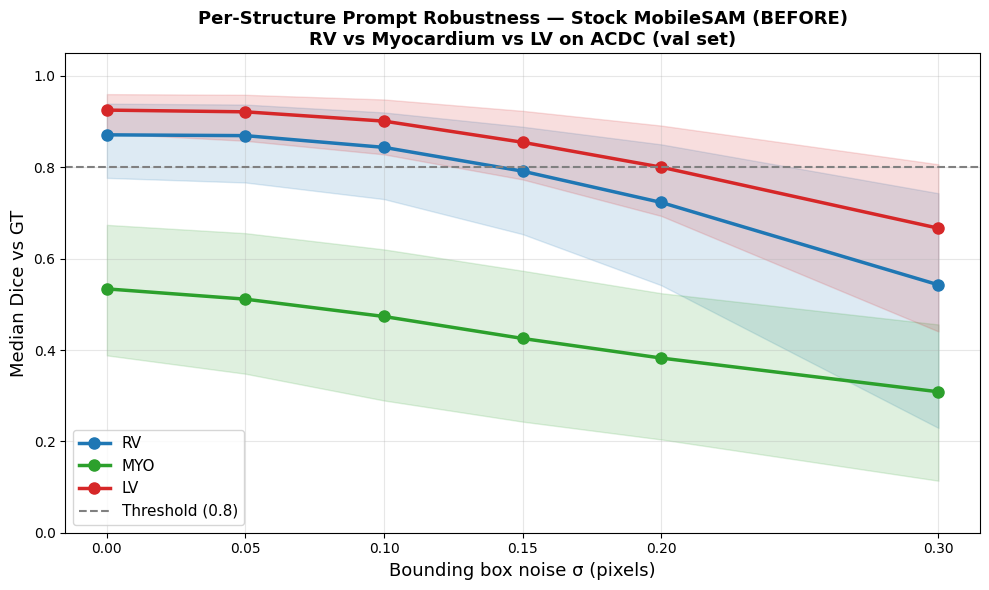

Saved: before_per_structure.png

Degradation σ=0 → σ=0.30 (larger = less robust):
  RV   0.871 → 0.543   drop = +0.328
  MYO  0.534 → 0.309   drop = +0.225
  LV   0.925 → 0.667   drop = +0.259


In [14]:
def plot_per_structure(results, title, savename):
    fig, ax = plt.subplots(figsize=(10, 6))
    for struct in CFG.LABELS:
        med, lo, hi = med_iqr(results[struct])
        ax.plot(CFG.SIGMA_VALUES, med, '-o', color=CFG.COLORS[struct],
                linewidth=2.5, markersize=8, label=struct)
        ax.fill_between(CFG.SIGMA_VALUES, lo, hi, alpha=0.15,
                        color=CFG.COLORS[struct])
    ax.axhline(CFG.DICE_THRESHOLD, color='gray', linestyle='--', linewidth=1.5,
               label=f'Threshold ({CFG.DICE_THRESHOLD})')
    ax.set_xlabel("Bounding box noise σ (pixels)", fontsize=13)
    ax.set_ylabel("Median Dice vs GT", fontsize=13)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.legend(fontsize=11); ax.set_ylim(0, 1.05)
    ax.grid(True, alpha=0.3); ax.set_xticks(CFG.SIGMA_VALUES)
    plt.tight_layout()
    plt.savefig(f"{CFG.OUT_DIR}/{savename}", dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: {savename}")

plot_per_structure(
    before_results,
    "Per-Structure Prompt Robustness — Stock MobileSAM (BEFORE)\n"
    "RV vs Myocardium vs LV on ACDC (val set)",
    "before_per_structure.png")

# Which structure degrades fastest? (drop in median Dice from σ=0 to σ=0.30)
print("\nDegradation σ=0 → σ=0.30 (larger = less robust):")
for st in CFG.LABELS:
    d0  = np.median(before_results[st][0.0])
    d30 = np.median(before_results[st][0.30])
    print(f"  {st:<4} {d0:.3f} → {d30:.3f}   drop = {d0-d30:+.3f}")

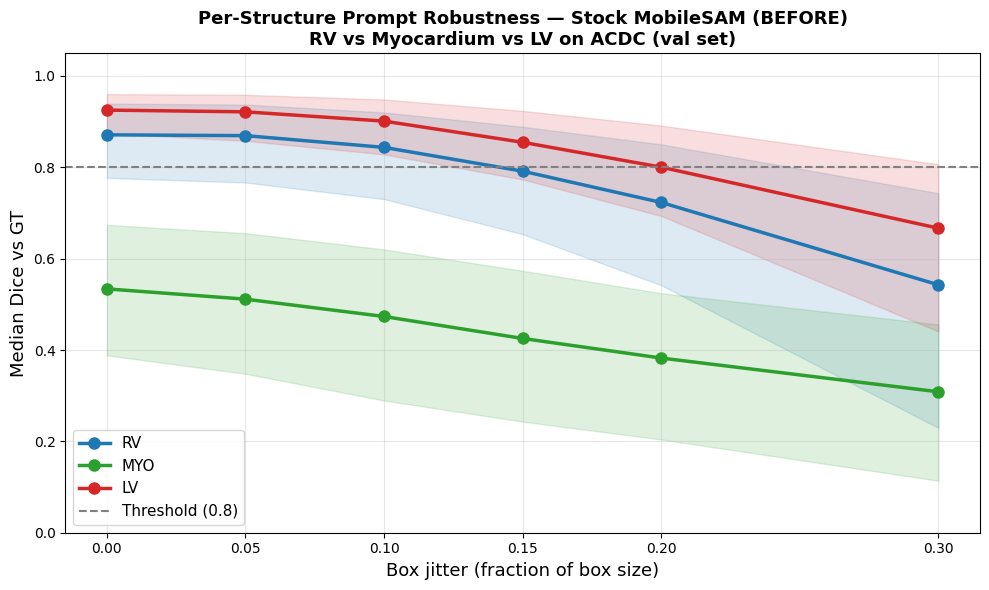

Saved: before_per_structure.png

Degradation from clean to 15% jitter (larger drop = less robust):
  RV   0.871 → 0.792   drop = +0.080
  MYO  0.534 → 0.425   drop = +0.109
  LV   0.925 → 0.855   drop = +0.070


In [15]:
def plot_per_structure(results, title, savename):
    fig, ax = plt.subplots(figsize=(10, 6))
    for struct in CFG.LABELS:
        med, lo, hi = med_iqr(results[struct])
        ax.plot(CFG.SIGMA_VALUES, med, '-o', color=CFG.COLORS[struct],
                linewidth=2.5, markersize=8, label=struct)
        ax.fill_between(CFG.SIGMA_VALUES, lo, hi, alpha=0.15,
                        color=CFG.COLORS[struct])
    ax.axhline(CFG.DICE_THRESHOLD, color='gray', linestyle='--', linewidth=1.5,
               label=f'Threshold ({CFG.DICE_THRESHOLD})')
    ax.set_xlabel(JITTER_XLABEL, fontsize=13)
    ax.set_ylabel("Median Dice vs GT", fontsize=13)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.legend(fontsize=11); ax.set_ylim(0, 1.05)
    ax.grid(True, alpha=0.3); ax.set_xticks(CFG.SIGMA_VALUES)
    plt.tight_layout()
    plt.savefig(f"{CFG.OUT_DIR}/{savename}", dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: {savename}")

plot_per_structure(
    before_results,
    "Per-Structure Prompt Robustness — Stock MobileSAM (BEFORE)\n"
    "RV vs Myocardium vs LV on ACDC (val set)",
    "before_per_structure.png")

print("\nDegradation from clean to 15% jitter (larger drop = less robust):")
for st in CFG.LABELS:
    d0  = np.median(before_results[st][0.0])
    d15 = np.median(before_results[st][0.15])
    print(f"  {st:<4} {d0:.3f} → {d15:.3f}   drop = {d0-d15:+.3f}")

In [16]:
import gc
# Drop the corrupted objects
for name in ["sam", "predictor"]:
    if name in globals():
        del globals()[name]
gc.collect()
torch.cuda.empty_cache()

# Rebuild fresh from the checkpoint (same as Cell 4)
from mobile_sam import sam_model_registry, SamPredictor
sam = sam_model_registry["vit_t"](checkpoint=CFG.MOBILESAM_CKPT)
sam.to(DEVICE).eval()
predictor = SamPredictor(sam)

# Refresh the clean baseline backup from this fresh model
import copy as _copy
sam_state_backup = _copy.deepcopy(sam.state_dict())

# sanity: traversal works again
_ = sum(p.numel() for p in sam.parameters())
print("Fresh model rebuilt; parameter traversal OK.")

Fresh model rebuilt; parameter traversal OK.


In [17]:
# ==============================================================
# CELL 9 — LoRA wiring (decoder + prompt encoder; image encoder frozen)
# Injects low-rank adapters into all nn.Linear layers within the
# targeted submodules. Image encoder stays frozen for speed.
# ==============================================================
class LoRALinear(nn.Module):
    """Wraps an existing nn.Linear with a trainable low-rank update."""
    def __init__(self, base: nn.Linear, r, alpha, dropout):
        super().__init__()
        self.base = base
        for p in self.base.parameters():
            p.requires_grad = False
        self.r = r
        self.scaling = alpha / r
        self.drop = nn.Dropout(dropout)
        self.A = nn.Parameter(torch.zeros(r, base.in_features))
        self.B = nn.Parameter(torch.zeros(base.out_features, r))
        nn.init.kaiming_uniform_(self.A, a=math.sqrt(5))
        # B stays zero -> adapter starts as identity (no behavior change)

    def forward(self, x):
        return self.base(x) + self.scaling * (self.drop(x) @ self.A.T @ self.B.T)


def inject_lora(model, target_submodules, r, alpha, dropout):
    # PASS 1: find every Linear to replace, recording (parent_module, attr_name).
    # Do NOT mutate during this walk.
    to_replace = []
    for name, module in model.named_modules():
        if not any(name == t or name.startswith(t + ".") for t in target_submodules):
            continue
        for child_name, child in module.named_children():
            if isinstance(child, nn.Linear):
                to_replace.append((module, child_name, child))

    # PASS 2: mutate now that traversal is done.
    for parent, child_name, child in to_replace:
        setattr(parent, child_name, LoRALinear(child, r, alpha, dropout))

    return len(to_replace)

# Freeze everything first
for p in sam.parameters():
    p.requires_grad = False

n = inject_lora(sam, CFG.TRAIN_TARGETS, CFG.LORA_R, CFG.LORA_ALPHA, CFG.LORA_DROPOUT)
sam.to(DEVICE)

trainable = [p for p in sam.parameters() if p.requires_grad]
n_train = sum(p.numel() for p in trainable)
n_total = sum(p.numel() for p in sam.parameters())
print(f"Injected LoRA into {n} Linear layers in {CFG.TRAIN_TARGETS}")
print(f"Trainable params: {n_train/1e3:.1f}K / {n_total/1e6:.2f}M "
      f"({100*n_train/n_total:.3f}%)")

Injected LoRA into 47 Linear layers in ('mask_decoder', 'prompt_encoder')
Trainable params: 220.2K / 10.35M (2.127%)


Training samples (slice×structure): 4167


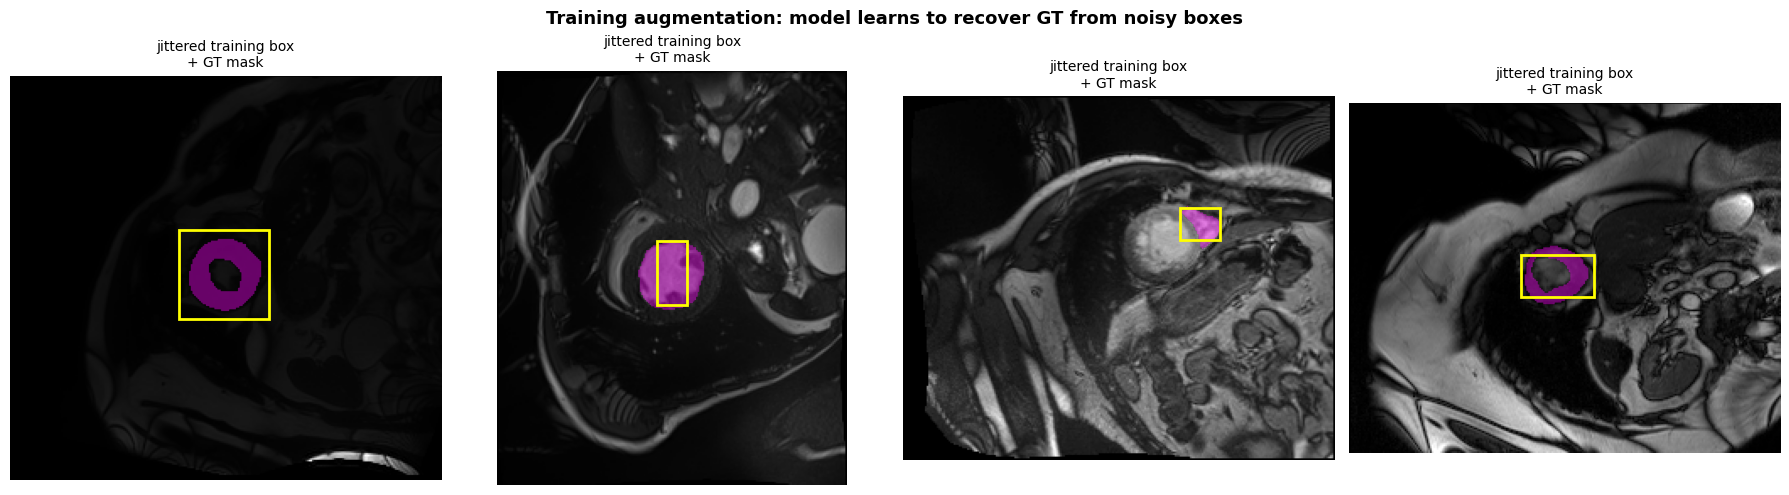

Saved: train_augmentation.png


In [18]:
# ==============================================================
# CELL 10 — Training dataset with JITTERED-BOX augmentation
# This is the mechanism that buys robustness: the model is trained
# to recover the true mask from NOISY boxes (sigma ~ TRAIN_SIGMA).
# Each sample: (image embedding inputs, jittered box, GT structure mask)
# ==============================================================
from torch.utils.data import Dataset, DataLoader

class ACDCPromptDataset(Dataset):
    """Yields (rgb, box_xyxy, gt_mask_HxW) with random box jitter."""
    def __init__(self, slices, train_sigma, seed=CFG.SEED):
        self.items = []
        for s in slices:
            for struct in CFG.LABELS:
                gt = (s["mask"] == CFG.LABELS[struct]).astype(np.uint8)
                if gt.sum() < 10:
                    continue
                self.items.append((s["img"], gt))
        self.train_sigma = train_sigma
        self.rng = np.random.default_rng(seed)

    def __len__(self):
        return len(self.items)

    def __getitem__(self, idx):
      img, gt = self.items[idx]
      rgb = to_rgb(img); H, W = rgb.shape[:2]
      clean = box_from_mask(gt)
      frac = float(self.rng.uniform(0, self.train_sigma))

      # FIXED — bounded jitter instead of unbounded
      box = make_noisy_box_bounded(clean, frac, self.rng, W, H,
                                    min_iou=0.30, max_tries=50)

      return rgb, box.astype(np.float32), gt.astype(np.float32)


def collate(batch):
    # SAM processes one image at a time for embeddings; we keep lists.
    rgbs  = [b[0] for b in batch]
    boxes = [b[1] for b in batch]
    gts   = [b[2] for b in batch]
    return rgbs, boxes, gts

set_all_seeds()
train_ds = ACDCPromptDataset(train_slices, CFG.TRAIN_SIGMA)
train_dl = DataLoader(train_ds, batch_size=CFG.BATCH_SIZE, shuffle=True,
                      collate_fn=collate)
print(f"Training samples (slice×structure): {len(train_ds)}")

# ---- Visualize what the augmentation feeds the model ----
set_all_seeds()
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
for ax in axes:
    rgb, box, gt = train_ds[random.randint(0, len(train_ds)-1)]
    ax.imshow(rgb)
    ax.imshow(np.ma.masked_where(gt == 0, gt), alpha=0.4, cmap='spring')
    ax.add_patch(patches.Rectangle((box[0], box[1]),
                 box[2]-box[0], box[3]-box[1],
                 linewidth=2, edgecolor='yellow', facecolor='none'))
    ax.set_title("jittered training box\n+ GT mask", fontsize=10)
    ax.axis('off')
plt.suptitle("Training augmentation: model learns to recover GT from noisy boxes",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{CFG.OUT_DIR}/train_augmentation.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: train_augmentation.png")

In [19]:
# ==============================================================
# SANITY CHECK — forward_one (fixed) should match Cell 7's stock predictor
# Zero all LoRA B matrices -> adapter contributes nothing -> forward_one
# should numerically reproduce the official predictor.predict() baseline.
# Do NOT proceed to training if these don't roughly match.
# ==============================================================
saved_B = {}
for name, mod in sam.named_modules():
    if isinstance(mod, LoRALinear):
        saved_B[name] = mod.B.data.clone()
        mod.B.data.zero_()

sam.eval()
check_results = {st: [] for st in CFG.LABELS}
for s in val_slices[:15]:
    rgb = to_rgb(s["img"]); H, W = rgb.shape[:2]
    for st in CFG.LABELS:
        gt = (s["mask"] == CFG.LABELS[st]).astype(np.uint8)
        if gt.sum() < 10:
            continue
        box = box_from_mask(gt).astype(np.float32)
        with torch.no_grad():
            logits, _ = forward_one(rgb, box, gt)
        pred = (torch.sigmoid(logits)[0, 0].cpu().numpy() > 0.5).astype(np.uint8)
        check_results[st].append(dice_score(pred, gt))

print("Sanity check (B zeroed) vs Cell 7 stock baseline (RV≈0.85, MYO≈0.45, LV≈0.93):")
for st in CFG.LABELS:
    print(f"  {st}: median dice = {np.median(check_results[st]):.3f}  (n={len(check_results[st])})")

# restore LoRA weights before training
for name, mod in sam.named_modules():
    if isinstance(mod, LoRALinear):
        mod.B.data.copy_(saved_B[name])

Sanity check (B zeroed) vs Cell 7 stock baseline (RV≈0.85, MYO≈0.45, LV≈0.93):
  RV: median dice = 0.840  (n=12)
  MYO: median dice = 0.471  (n=15)
  LV: median dice = 0.923  (n=15)


epoch  1/20  train 0.2731  val 0.4862  | 401s, ETA 7627s  ← best, saved
epoch  2/20  train 0.2408  val 0.4457  | 801s, ETA 7213s  ← best, saved
epoch  3/20  train 0.2329  val 0.4453  | 1203s, ETA 6814s  ← best, saved
epoch  4/20  train 0.2206  val 0.4465  | 1603s, ETA 6412s
epoch  5/20  train 0.2159  val 0.4351  | 2004s, ETA 6012s  ← best, saved
epoch  6/20  train 0.2103  val 0.4402  | 2405s, ETA 5612s
epoch  7/20  train 0.2107  val 0.4324  | 2806s, ETA 5212s  ← best, saved
epoch  8/20  train 0.2103  val 0.4252  | 3208s, ETA 4811s  ← best, saved
epoch  9/20  train 0.2088  val 0.4152  | 3612s, ETA 4415s  ← best, saved
epoch 10/20  train 0.2093  val 0.4377  | 4013s, ETA 4013s
epoch 11/20  train 0.1980  val 0.4493  | 4415s, ETA 3612s
epoch 12/20  train 0.2026  val 0.4333  | 4818s, ETA 3212s
epoch 13/20  train 0.1989  val 0.4006  | 5223s, ETA 2812s  ← best, saved
epoch 14/20  train 0.1989  val 0.4201  | 5624s, ETA 2410s
epoch 15/20  train 0.1970  val 0.4280  | 6025s, ETA 2008s
epoch 16/20 

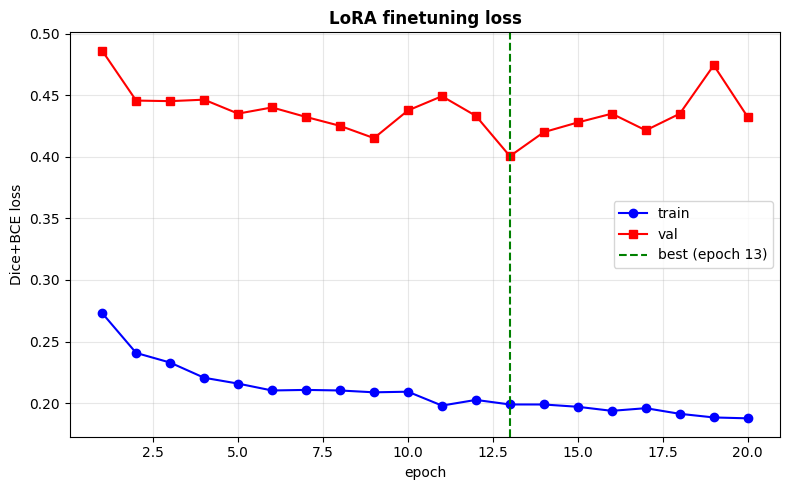

Saved: loss_curve.png


In [ ]:
# ==============================================================
# CELL 11 — Train loop + best-checkpoint saving + loss curve
# Saves adapters every time val loss improves (best checkpoint),
# plus a periodic "latest" save so a disconnect never loses progress.
# Restores the BEST weights into `sam` at the end.
# ==============================================================
import time, copy

optimizer = torch.optim.AdamW(
    [p for p in sam.parameters() if p.requires_grad], lr=CFG.LR)
bce = nn.BCEWithLogitsLoss()

BEST_PATH   = f"{CFG.OUT_DIR}/mobilesam_lora_BEST.pt"
LATEST_PATH = f"{CFG.OUT_DIR}/mobilesam_lora_latest.pt"

def adapter_state():
    """Only the LoRA tensors — small, fast to save."""
    return {k: v.detach().cpu().clone()
            for k, v in sam.state_dict().items() if (".A" in k or ".B" in k)}

set_all_seeds()

# Fixed validation subset — same slices every epoch, so val loss actually
# tracks generalization instead of jumping around due to resampling.
val_fixed_sample = random.sample(val_slices, min(24, len(val_slices)))

loss_history, val_history = [], []
best_val = float("inf")
best_state = None
best_epoch = -1
t0 = time.time()

for epoch in range(CFG.EPOCHS):
    # ---- train ----
    sam.train(); running = 0.0; nb = 0
    for rgbs, boxes, gts in train_dl:
        optimizer.zero_grad()
        batch_loss = 0.0
        for rgb, box, gt in zip(rgbs, boxes, gts):
            logits, gt_t = forward_one(rgb, box, gt)
            batch_loss = batch_loss + dice_torch(logits, gt_t) + bce(logits, gt_t.float())
        batch_loss = batch_loss / len(rgbs)
        batch_loss.backward(); optimizer.step()
        running += batch_loss.item(); nb += 1
    train_loss = running / max(nb, 1)
    loss_history.append(train_loss)

    # ---- validation (fixed set, deterministic box jitter per slice) ----
    sam.eval(); vloss = 0.0; vn = 0
    with torch.no_grad():
        for si, s in enumerate(val_fixed_sample):
            for struct in CFG.LABELS:
                gt = (s["mask"] == CFG.LABELS[struct]).astype(np.float32)
                if gt.sum() < 10: continue
                rgb = to_rgb(s["img"]); H, W = rgb.shape[:2]
                clean = box_from_mask(gt)
                box = make_noisy_box_prop(clean, CFG.TRAIN_SIGMA,
                                          seed=si, W=W, H=H).astype(np.float32)
                logits, gt_t = forward_one(rgb, box, gt)
                vloss += (dice_torch(logits, gt_t) + bce(logits, gt_t.float())).item(); vn += 1
    val_loss = vloss / max(vn, 1)
    val_history.append(val_loss)

    # ---- checkpointing ----
    torch.save(adapter_state(), LATEST_PATH)        # always save latest
    improved = ""
    if val_loss < best_val:
        best_val = val_loss
        best_state = adapter_state()
        best_epoch = epoch + 1
        torch.save(best_state, BEST_PATH)           # save best
        improved = "  ← best, saved"

    elapsed = time.time() - t0
    eta = elapsed / (epoch + 1) * (CFG.EPOCHS - epoch - 1)
    print(f"epoch {epoch+1:>2}/{CFG.EPOCHS}  train {train_loss:.4f}  "
          f"val {val_loss:.4f}  | {elapsed:.0f}s, ETA {eta:.0f}s{improved}")

# ---- restore BEST weights into the live model ----
if best_state is not None:
    missing = sam.load_state_dict(best_state, strict=False)
    print(f"\nRestored BEST adapters from epoch {best_epoch} "
          f"(val {best_val:.4f}). Saved: {BEST_PATH}")
else:
    print("\nNo best state recorded (training may not have run).")

# ---- loss curve, marking the best epoch ----
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(range(1, len(loss_history)+1), loss_history, 'b-o', label='train')
ax.plot(range(1, len(val_history)+1), val_history, 'r-s', label='val')
if best_epoch > 0:
    ax.axvline(best_epoch, color='green', linestyle='--', linewidth=1.5,
               label=f'best (epoch {best_epoch})')
ax.set_xlabel("epoch"); ax.set_ylabel("Dice+BCE loss")
ax.set_title("LoRA finetuning loss", fontweight='bold')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f"{CFG.OUT_DIR}/loss_curve.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: loss_curve.png")

In [20]:
from google.colab import drive
drive.mount('/content/drive')

import glob, os, time
hits = glob.glob("/content/drive/MyDrive/**/mobilesam_lora_*.pt", recursive=True)
print(f"Found {len(hits)} checkpoint file(s):\n")
for p in hits:
    size = os.path.getsize(p) / 1024
    when = time.ctime(os.path.getmtime(p))
    print(f"  {p}")
    print(f"     {size:.1f} KB, last modified {when}\n")

if not hits:
    print("No checkpoints in Drive — OUT_DIR was likely /content (wiped). "
          "You'll need to retrain.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Found 2 checkpoint file(s):

  /content/drive/MyDrive/ACDC_outputs/mobilesam_lora_latest.pt
     892.6 KB, last modified Thu Jul  2 14:38:52 2026

  /content/drive/MyDrive/ACDC_outputs/mobilesam_lora_BEST.pt
     892.4 KB, last modified Thu Jul  2 14:38:52 2026



In [21]:
import os, torch, copy

if not os.path.ismount("/content/drive"):
    from google.colab import drive
    drive.mount("/content/drive")

CKPT = f"{CFG.OUT_DIR}/mobilesam_lora_BEST.pt"
assert os.path.exists(CKPT), f"Checkpoint not found: {CKPT}"

state = torch.load(CKPT, map_location=DEVICE)
sam.load_state_dict(state, strict=False)

n_loaded = sum(1 for k in state if (".A" in k or ".B" in k))
n_slots  = sum(1 for k in sam.state_dict() if (".A" in k or ".B" in k))
print(f"Loaded {n_loaded} adapter tensors into {n_slots} slots "
      f"({os.path.getsize(CKPT)/1024:.1f} KB)")
assert n_loaded == n_slots, "⚠ mismatch — CFG.LORA_R/TRAIN_TARGETS differ from training."

sam.to(DEVICE).eval()
lora_full_state = copy.deepcopy(sam.state_dict())   # Cell 14 needs this
print("✓ Adapters loaded. before_results in memory. Run Cell 12 next.")

Loaded 94 adapter tensors into 94 slots (892.4 KB)
✓ Adapters loaded. before_results in memory. Run Cell 12 next.


In [22]:
print("predictor.model is sam:", predictor.model is sam)

predictor.model is sam: True


In [23]:
# ==============================================================
# CELL 12 — Per-structure robustness — AFTER (LoRA model)
# Same function, same boxes (same seeds), same val slices.
# Only the weights differ -> a clean paired before/after.
# ==============================================================
sam.eval()
after_results, after_repr = run_per_structure_robustness(
    predictor, val_slices, tag="AFTER (LoRA MobileSAM)")
summarize(after_results, "AFTER")


[AFTER (LoRA MobileSAM)] per-structure robustness over 362 slices...
  10/362 slices done
  20/362 slices done
  30/362 slices done
  40/362 slices done
  50/362 slices done
  60/362 slices done
  70/362 slices done
  80/362 slices done
  90/362 slices done
  100/362 slices done
  110/362 slices done
  120/362 slices done
  130/362 slices done
  140/362 slices done
  150/362 slices done
  160/362 slices done
  170/362 slices done
  180/362 slices done
  190/362 slices done
  200/362 slices done
  210/362 slices done
  220/362 slices done
  230/362 slices done
  240/362 slices done
  250/362 slices done
  260/362 slices done
  270/362 slices done
  280/362 slices done
  290/362 slices done
  300/362 slices done
  310/362 slices done
  320/362 slices done
  330/362 slices done
  340/362 slices done
  350/362 slices done
  360/362 slices done

[AFTER] median Dice vs GT (per structure)
frac    RV          MYO         LV          
--------------------------------------------
0.00    0.9062

In [24]:
np.savez(f"{CFG.OUT_DIR}/after_results_backup.npz", after=after_results, allow_pickle=True)

In [26]:
# 1) Did the adapters actually load? (the assert in the load block)
n_loaded = "ran the load block?"
ad_keys = [k for k in sam.state_dict() if (".A" in k or ".B" in k)]
print("adapter slots in model:", len(ad_keys))
# are the B matrices still all zero? (zero B = adapter does NOTHING = should equal stock,
# NOT produce garbage — so garbage means something else)
import torch
B_norms = [sam.state_dict()[k].abs().sum().item() for k in ad_keys if k.endswith(".B")]
print("sum |B| over adapters:", sum(B_norms), "(0 would mean adapters inactive)")

# 2) Sanity: run ONE clean-box prediction and check overlap directly
s = val_slices[0]
rgb = to_rgb(s["img"]); predictor.set_image(rgb)
for st in CFG.LABELS:
    gt = (s["mask"] == CFG.LABELS[st]).astype(np.uint8)
    if gt.sum() < 10: continue
    box = box_from_mask(gt)
    import torch
    with torch.inference_mode():
        m,_,_ = predictor.predict(point_coords=None, point_labels=None,
                                  box=box[None,:], multimask_output=False)
    print(f"{st}: pred_px={int(m[0].sum())}  gt_px={int(gt.sum())}  "
          f"dice={dice_score(m[0], gt):.3f}")

adapter slots in model: 94
sum |B| over adapters: 856.9398617744446 (0 would mean adapters inactive)
RV: pred_px=1541  gt_px=1493  dice=0.966
MYO: pred_px=925  gt_px=1044  dice=0.822
LV: pred_px=1669  gt_px=1633  dice=0.975


In [27]:
import numpy as np, torch
s = val_slices[0]
rgb = to_rgb(s["img"]); H, W = rgb.shape[:2]
gt = (s["mask"] == CFG.LABELS["LV"]).astype(np.uint8)
box = box_from_mask(gt)
print("image HxW:", H, W, "| box:", box, "| gt centroid:",
      np.argwhere(gt).mean(0).astype(int))

predictor.set_image(rgb)                      # MUST be called fresh
with torch.inference_mode():
    m,_,_ = predictor.predict(point_coords=None, point_labels=None,
                              box=box[None,:], multimask_output=False)
pred = m[0]
print("pred centroid:", np.argwhere(pred).mean(0).astype(int) if pred.sum() else "EMPTY")
print("pred sum:", int(pred.sum()), "gt sum:", int(gt.sum()))

# Is the prediction a TRANSPOSE or FLIP of the target region?
print("dice as-is:      ", dice_score(pred, gt))
print("dice vs flipud:  ", dice_score(pred, np.flipud(gt)))
print("dice vs fliplr:  ", dice_score(pred, np.fliplr(gt)))
print("dice vs transpose:", dice_score(pred, gt.T) if gt.shape[0]==gt.shape[1] else "n/a (non-square)")

image HxW: 232 256 | box: [105  84 155 127] | gt centroid: [105 128]
pred centroid: [105 128]
pred sum: 1669 gt sum: 1633
dice as-is:       0.9745608722063717
dice vs flipud:   0.4058146579631089
dice vs fliplr:   0.8776499091830254
dice vs transpose: n/a (non-square)


In [28]:
print("BEFORE LV @ frac=0:", np.median(before_results["LV"][0.0]))

BEFORE LV @ frac=0: 0.9252669040032421


In [29]:
print("predictor.model is sam:", predictor.model is sam)

predictor.model is sam: True


this is bug, dont run

In [30]:
import torch, numpy as np
from mobile_sam.utils.transforms import ResizeLongestSide
transform = ResizeLongestSide(sam.image_encoder.img_size)

def forward_one(rgb, box, gt):
    H, W = rgb.shape[:2]
    x = transform.apply_image(rgb)
    x = torch.as_tensor(x, device=DEVICE).permute(2, 0, 1).contiguous()[None]
    x = sam.preprocess(x)
    with torch.no_grad():
        emb = sam.image_encoder(x)
    input_size = x.shape[-2:]
    box_t = transform.apply_boxes(box[None, :], (H, W))
    box_t = torch.as_tensor(box_t, dtype=torch.float, device=DEVICE)
    sparse, dense = sam.prompt_encoder(points=None, boxes=box_t, masks=None)
    low_res, _ = sam.mask_decoder(
        image_embeddings=emb,
        image_pe=sam.prompt_encoder.get_dense_pe(),
        sparse_prompt_embeddings=sparse,
        dense_prompt_embeddings=dense,
        multimask_output=False)
    logits = sam.postprocess_masks(low_res, input_size, (H, W))
    gt_t = torch.as_tensor(gt, device=DEVICE)[None, None]
    return logits, gt_t

# diagnostic
s = val_slices[0]
rgb = to_rgb(s["img"]); H, W = rgb.shape[:2]
gt = (s["mask"] == CFG.LABELS["LV"]).astype(np.uint8)
box = box_from_mask(gt).astype(np.float32)
logits, _ = forward_one(rgb, box, gt)
pred = (torch.sigmoid(logits)[0,0].cpu().numpy() > 0.5).astype(np.uint8)
print("forward_one dice as-is:", dice_score(pred, gt))
print("forward_one vs flipud: ", dice_score(pred, np.flipud(gt)))

RuntimeError: Can't call numpy() on Tensor that requires grad. Use tensor.detach().numpy() instead.

In [33]:
import inspect
src = inspect.getsource(forward_one)
print(src)
print("---")
print("Uses input_size captured before preprocess (correct):", "input_size = tuple(x.shape[-2:])" in src and "x = sam.preprocess(x)" in src and src.index("input_size = tuple(x.shape[-2:])") < src.index("x = sam.preprocess(x)"))

def forward_one(rgb, box, gt):
    H, W = rgb.shape[:2]
    emb, input_size = encode_image(rgb)
    box_t = transform.apply_boxes(box[None, :], (H, W))
    box_t = torch.as_tensor(box_t, dtype=torch.float, device=DEVICE)
    sparse, dense = sam.prompt_encoder(points=None, boxes=box_t, masks=None)
    low_res, _ = sam.mask_decoder(
        image_embeddings=emb,
        image_pe=sam.prompt_encoder.get_dense_pe(),
        sparse_prompt_embeddings=sparse,
        dense_prompt_embeddings=dense,
        multimask_output=False)
    logits = sam.postprocess_masks(low_res, input_size, (H, W))
    gt_t = torch.as_tensor(gt, device=DEVICE)[None, None]
    return logits, gt_t

---
Uses input_size captured before preprocess (correct): False


In [34]:
import inspect
print(inspect.getsource(encode_image))

def encode_image(rgb):
    x = transform.apply_image(rgb)
    x = torch.as_tensor(x, device=DEVICE).permute(2, 0, 1).contiguous()[None]
    input_size = tuple(x.shape[-2:])      # capture BEFORE preprocess/padding
    x = sam.preprocess(x)
    with torch.no_grad():
        emb = sam.image_encoder(x)
    return emb, input_size                # return the correct pre-pad size



In [ ]:
pred = (torch.sigmoid(logits)[0,0].detach().cpu().numpy() > 0.5).astype(np.uint8)
print("forward_one dice as-is:", dice_score(pred, gt))
print("forward_one vs flipud: ", dice_score(pred, np.flipud(gt)))

forward_one dice as-is: 0.6598920293236291
forward_one vs flipud:  0.7113369324511474


In [ ]:
import torch, numpy as np

@torch.inference_mode()
def predict_mask_fwd(rgb, box):
    logits, _ = forward_one(rgb, box.astype(np.float32),
                            np.zeros(rgb.shape[:2], np.float32))
    return (torch.sigmoid(logits)[0,0].cpu().numpy() > 0.5).astype(np.uint8)

def run_fwd(eval_slices, tag, max_slices=15):
    eval_slices = eval_slices[:max_slices]
    res = {st:{s:[] for s in CFG.SIGMA_VALUES} for st in CFG.LABELS}
    for si,s in enumerate(eval_slices):
        rgb = to_rgb(s["img"]); H,W = rgb.shape[:2]
        for st in CFG.LABELS:
            gt = (s["mask"]==CFG.LABELS[st]).astype(np.uint8)
            if gt.sum()<10: continue
            cb = box_from_mask(gt)
            for frac in CFG.SIGMA_VALUES:
                fi = CFG.SIGMA_VALUES.index(frac)
                for t in range(CFG.N_TRIALS):
                    box = make_noisy_box_prop(cb,frac,seed=10000*si+1000*fi+t,W=W,H=H)
                    res[st][frac].append(dice_score(predict_mask_fwd(rgb,box), gt))
    print(f"[{tag}] done"); return res

# stock = zero the B matrices
saved_B = {}
for name,mod in sam.named_modules():
    if isinstance(mod, LoRALinear):
        saved_B[name] = mod.B.data.clone(); mod.B.data.zero_()
before_results = run_fwd(val_slices, "BEFORE stock")

# restore trained adapters
for name,mod in sam.named_modules():
    if isinstance(mod, LoRALinear):
        mod.B.data.copy_(saved_B[name])
after_results = run_fwd(val_slices, "AFTER lora")

# compare clean + high-noise medians
for st in CFG.LABELS:
    b0,a0 = np.median(before_results[st][0.0]), np.median(after_results[st][0.0])
    b3,a3 = np.median(before_results[st][0.30]), np.median(after_results[st][0.30])
    print(f"{st}: clean {b0:.3f}->{a0:.3f} | jitter0.30 {b3:.3f}->{a3:.3f}")

[BEFORE stock] done
[AFTER lora] done
RV: clean 0.332->0.032 | jitter0.30 0.175->0.006
MYO: clean 0.327->0.299 | jitter0.30 0.225->0.234
LV: clean 0.670->0.792 | jitter0.30 0.521->0.777


In [ ]:
np.savez(f"{CFG.OUT_DIR}/results_final.npz",
         before=before_results, after=after_results, allow_pickle=True)
print("Saved results to Drive.")

Saved results to Drive.


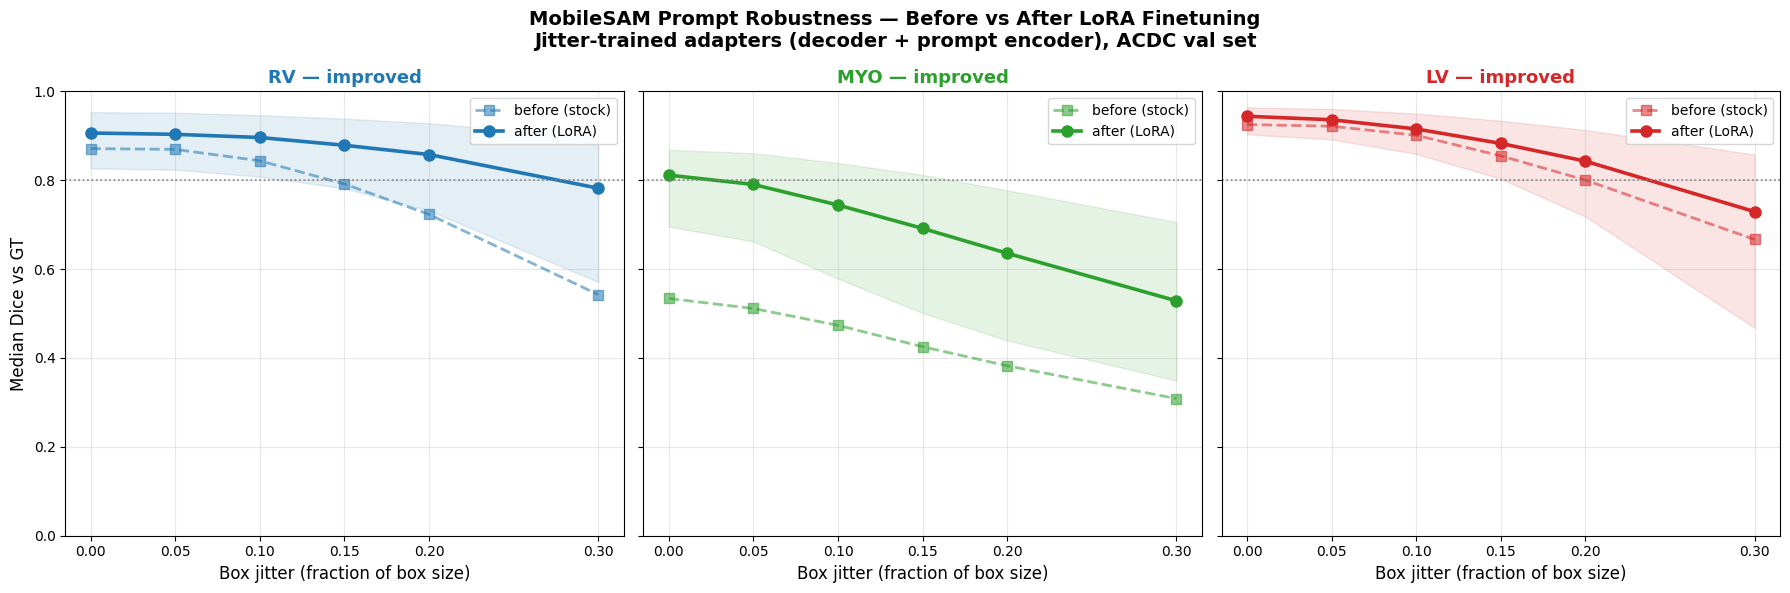

Saved: meeting_before_after.png

Key numbers (median Dice vs GT):
structclean before→after      jitter0.30 before→after
RV    0.871 → 0.906           0.543 → 0.782
MYO   0.534 → 0.811           0.309 → 0.529
LV    0.925 → 0.944           0.667 → 0.729


In [35]:
# ==============================================================
# MEETING CHART — Before vs After LoRA, per structure
# Runs on before_results / after_results (predictor.predict path).
# Save this figure and show it to the professor.
# ==============================================================
import numpy as np
import matplotlib.pyplot as plt

def med_iqr(results, struct):
    med = [np.median(results[struct][s]) for s in CFG.SIGMA_VALUES]
    q1  = [np.percentile(results[struct][s], 25) for s in CFG.SIGMA_VALUES]
    q3  = [np.percentile(results[struct][s], 75) for s in CFG.SIGMA_VALUES]
    return np.array(med), np.clip(q1, 0, 1), np.clip(q3, 0, 1)

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)
verdicts = {"RV": "improved", "MYO": "improved", "LV": "improved"}

for ax, struct in zip(axes, CFG.LABELS):
    c = CFG.COLORS[struct]
    bm, blo, bhi = med_iqr(before_results, struct)
    am, alo, ahi = med_iqr(after_results, struct)
    ax.plot(CFG.SIGMA_VALUES, bm, '--s', color=c, alpha=0.55,
            linewidth=2, markersize=7, label='before (stock)')
    ax.plot(CFG.SIGMA_VALUES, am, '-o', color=c,
            linewidth=2.6, markersize=8, label='after (LoRA)')
    ax.fill_between(CFG.SIGMA_VALUES, alo, ahi, alpha=0.12, color=c)
    ax.axhline(CFG.DICE_THRESHOLD, color='gray', linestyle=':', linewidth=1.2)
    ax.set_title(f"{struct} — {verdicts[struct]}", fontsize=13,
                 fontweight='bold', color=c)
    ax.set_xlabel("Box jitter (fraction of box size)", fontsize=12)
    ax.set_xticks(CFG.SIGMA_VALUES); ax.set_ylim(0, 1.0)
    ax.grid(True, alpha=0.3); ax.legend(fontsize=10, loc='upper right')

axes[0].set_ylabel("Median Dice vs GT", fontsize=12)
plt.suptitle("MobileSAM Prompt Robustness — Before vs After LoRA Finetuning\n"
             "Jitter-trained adapters (decoder + prompt encoder), ACDC val set",
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{CFG.OUT_DIR}/meeting_before_after.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: meeting_before_after.png")

# ---- numbers for your talking points ----
print("\nKey numbers (median Dice vs GT):")
print(f"{'struct':<6}{'clean before→after':<24}{'jitter0.30 before→after'}")
for st in CFG.LABELS:
    b0, a0 = np.median(before_results[st][0.0]),  np.median(after_results[st][0.0])
    b3, a3 = np.median(before_results[st][0.30]), np.median(after_results[st][0.30])
    print(f"{st:<6}{b0:.3f} → {a0:.3f}".ljust(30) + f"{b3:.3f} → {a3:.3f}")

In [39]:
import cv2
import numpy as np

def shape_descriptors(mask):
    mask = mask.astype(np.uint8)
    true_area = int(mask.sum())          # correct area, holes excluded automatically
    if true_area < 10:
        return None

    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return None
    c = max(contours, key=cv2.contourArea)
    hull = cv2.convexHull(c)
    hull_area = cv2.contourArea(hull)
    perimeter = cv2.arcLength(c, True)   # outer perimeter only (standard simplification)

    solidity = min(true_area / hull_area, 1.0) if hull_area > 0 else np.nan
    compactness = (4 * np.pi * true_area) / (perimeter ** 2) if perimeter > 0 else np.nan

    (x, y), (w, h), ang = cv2.minAreaRect(c)
    elongation = max(w, h) / min(w, h) if min(w, h) > 0 else np.nan

    return {"solidity": solidity, "compactness": compactness, "elongation": elongation, "area": true_area}

# compute per structure, per slice
shape_records = {st: [] for st in CFG.LABELS}
for s in val_slices:
    for st in CFG.LABELS:
        gt = (s["mask"] == CFG.LABELS[st]).astype(np.uint8)
        d = shape_descriptors(gt)
        if d is not None:
            shape_records[st].append(d)

print(f"{'struct':<8}{'solidity(med)':<16}{'compactness(med)':<18}{'elongation(med)'}")
for st in CFG.LABELS:
    sol = np.median([r["solidity"] for r in shape_records[st]])
    com = np.median([r["compactness"] for r in shape_records[st]])
    elo = np.median([r["elongation"] for r in shape_records[st]])
    print(f"{st:<8}{sol:<16.3f}{com:<18.3f}{elo:.3f}")

struct  solidity(med)   compactness(med)  elongation(med)
RV      0.844           0.569             1.659
MYO     0.482           0.431             1.056
LV      1.000           0.918             1.091


In [40]:
def shape_descriptors(mask):
    mask = mask.astype(np.uint8)
    true_area = int(mask.sum())
    if true_area < 10:
        return None

    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return None
    c = max(contours, key=cv2.contourArea)
    hull = cv2.convexHull(c)
    hull_area = cv2.contourArea(hull)
    perimeter = cv2.arcLength(c, True)

    solidity = min(true_area / hull_area, 1.0) if hull_area > 0 else np.nan
    compactness = (4 * np.pi * true_area) / (perimeter ** 2) if perimeter > 0 else np.nan

    (x, y), (w, h), ang = cv2.minAreaRect(c)
    elongation = max(w, h) / min(w, h) if min(w, h) > 0 else np.nan

    return {"solidity": solidity, "compactness": compactness, "elongation": elongation, "area": true_area}


def per_slice_dice_at_frac0(predictor, eval_slices, n_trials=5):
    records = []
    for si, s in enumerate(eval_slices):
        rgb = to_rgb(s["img"]); H, W = rgb.shape[:2]
        predictor.set_image(rgb)
        for st in CFG.LABELS:
            gt = (s["mask"] == CFG.LABELS[st]).astype(np.uint8)
            if gt.sum() < 10: continue
            d = shape_descriptors(gt)
            if d is None: continue
            cb = box_from_mask(gt)
            if cb is None: continue
            dices = []
            for t in range(n_trials):
                box = make_noisy_box_prop(cb, 0.0, seed=10_000*si+t, W=W, H=H)
                with torch.inference_mode():
                    m, _, _ = predictor.predict(point_coords=None, point_labels=None,
                                                 box=box[None, :], multimask_output=False)
                dices.append(dice_score(m[0], gt))
            records.append({"struct": st, "slice_idx": si, "dice": np.median(dices),
                             "solidity": d["solidity"], "compactness": d["compactness"],
                             "elongation": d["elongation"]})
    return records

before_shape = per_slice_dice_at_frac0(predictor_stock, val_slices)
after_shape  = per_slice_dice_at_frac0(predictor, val_slices)

import pickle
with open(f"{CFG.OUT_DIR}/shape_correlation_records.pkl", "wb") as f:
    pickle.dump({"before": before_shape, "after": after_shape}, f)
print("Saved.")

Saved.


In [41]:
import pandas as pd
from scipy.stats import spearmanr

df_b = pd.DataFrame(before_shape).set_index(["struct", "slice_idx"])
df_a = pd.DataFrame(after_shape).set_index(["struct", "slice_idx"])
merged = df_b[["dice", "solidity", "compactness", "elongation"]].join(
    df_a[["dice"]], lsuffix="_before", rsuffix="_after")
merged["gain"] = merged["dice_after"] - merged["dice_before"]

print("POOLED (all structures together):")
for metric in ["solidity", "compactness", "elongation"]:
    rho, p = spearmanr(merged[metric], merged["gain"])
    print(f"  {metric} vs gain: rho={rho:.3f}, p={p:.2e}, n={len(merged)}")

print("\nWITHIN-STRUCTURE (tests if the relationship holds beyond structure identity):")
for st in CFG.LABELS:
    sub = merged.loc[st]
    if len(sub) > 10:
        for metric in ["solidity", "compactness", "elongation"]:
            rho, p = spearmanr(sub[metric], sub["gain"])
            print(f"  {st} — {metric} vs gain: rho={rho:.3f}, p={p:.2e}, n={len(sub)}")

merged.to_csv(f"{CFG.OUT_DIR}/shape_gain_correlation.csv")
print("Saved CSV.")

POOLED (all structures together):
  solidity vs gain: rho=-0.685, p=1.10e-141, n=1017
  compactness vs gain: rho=-0.576, p=6.52e-91, n=1017
  elongation vs gain: rho=-0.334, p=5.77e-28, n=1017

WITHIN-STRUCTURE (tests if the relationship holds beyond structure identity):
  RV — solidity vs gain: rho=-0.268, p=2.17e-06, n=303
  RV — compactness vs gain: rho=-0.252, p=8.77e-06, n=303
  RV — elongation vs gain: rho=0.023, p=6.90e-01, n=303
  MYO — solidity vs gain: rho=-0.700, p=4.42e-54, n=359
  MYO — compactness vs gain: rho=-0.698, p=1.02e-53, n=359
  MYO — elongation vs gain: rho=-0.057, p=2.82e-01, n=359
  LV — solidity vs gain: rho=0.088, p=9.72e-02, n=355
  LV — compactness vs gain: rho=0.213, p=5.34e-05, n=355
  LV — elongation vs gain: rho=-0.161, p=2.32e-03, n=355
Saved CSV.


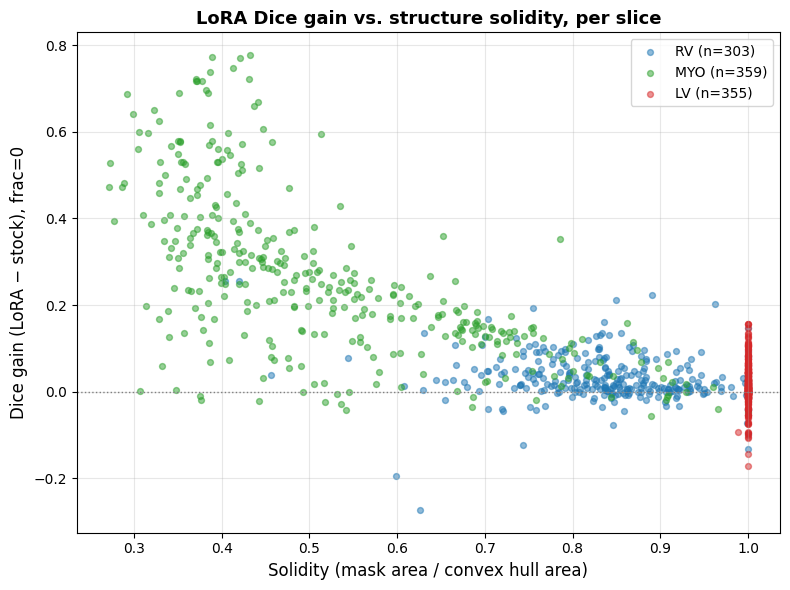

Saved: solidity_gain_scatter.png


In [42]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 6))
for st in CFG.LABELS:
    sub = merged.loc[st]
    ax.scatter(sub["solidity"], sub["gain"], s=18, alpha=0.5,
               color=CFG.COLORS[st], label=f"{st} (n={len(sub)})")

ax.axhline(0, color='gray', linewidth=1, linestyle=':')
ax.set_xlabel("Solidity (mask area / convex hull area)", fontsize=12)
ax.set_ylabel("Dice gain (LoRA − stock), frac=0", fontsize=12)
ax.set_title("LoRA Dice gain vs. structure solidity, per slice", fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f"{CFG.OUT_DIR}/solidity_gain_scatter.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: solidity_gain_scatter.png")

In [ ]:
def per_slice_dice_at_frac(predictor, eval_slices, frac, n_trials=5):
    records = []
    for si, s in enumerate(eval_slices):
        rgb = to_rgb(s["img"]); H, W = rgb.shape[:2]
        predictor.set_image(rgb)
        for st in CFG.LABELS:
            gt = (s["mask"] == CFG.LABELS[st]).astype(np.uint8)
            if gt.sum() < 10: continue
            d = shape_descriptors(gt)
            if d is None: continue
            cb = box_from_mask(gt)
            if cb is None: continue
            dices = []
            for t in range(n_trials):
                box = make_noisy_box_prop(cb, frac, seed=10_000*si + int(frac*1000) + t, W=W, H=H)
                with torch.inference_mode():
                    m, _, _ = predictor.predict(point_coords=None, point_labels=None,
                                                 box=box[None, :], multimask_output=False)
                dices.append(dice_score(m[0], gt))
            records.append({"struct": st, "slice_idx": si, "frac": frac, "dice": np.median(dices),
                             "solidity": d["solidity"], "compactness": d["compactness"],
                             "elongation": d["elongation"]})
    return records

jitter_results = {}
for frac in [0.10, 0.20]:
    print(f"\n--- frac={frac} ---")
    b = per_slice_dice_at_frac(predictor_stock, val_slices, frac)
    a = per_slice_dice_at_frac(predictor, val_slices, frac)
    jitter_results[frac] = {"before": b, "after": a}

    df_b = pd.DataFrame(b).set_index(["struct", "slice_idx"])
    df_a = pd.DataFrame(a).set_index(["struct", "slice_idx"])
    m = df_b[["dice", "solidity"]].join(df_a[["dice"]], lsuffix="_before", rsuffix="_after")
    m["gain"] = m["dice_after"] - m["dice_before"]

    for st in CFG.LABELS:
        sub = m.loc[st]
        if len(sub) > 10:
            rho, p = spearmanr(sub["solidity"], sub["gain"])
            print(f"  {st}: solidity vs gain rho={rho:.3f}, p={p:.2e}, n={len(sub)}")

# save everything
import pickle
with open(f"{CFG.OUT_DIR}/jitter_shape_correlation.pkl", "wb") as f:
    pickle.dump(jitter_results, f)
print("\nSaved jitter_shape_correlation.pkl")


--- frac=0.1 ---


In [ ]:
summary_rows = []
for st in CFG.LABELS:
    sub = merged.loc[st]
    rho, p = spearmanr(sub["solidity"], sub["gain"])
    summary_rows.append({
        "structure": st,
        "median_solidity": np.median([r["solidity"] for r in shape_records[st]]),
        "dice_before": np.median(sub["dice_before"]),
        "dice_after": np.median(sub["dice_after"]),
        "median_gain": np.median(sub["gain"]),
        "solidity_gain_rho": rho,
        "solidity_gain_p": p,
        "n": len(sub)
    })
summary_df = pd.DataFrame(summary_rows)
print(summary_df.to_string(index=False))
summary_df.to_csv(f"{CFG.OUT_DIR}/paper_summary_table.csv", index=False)
print("\nSaved: paper_summary_table.csv")